# 社會網絡分析與地理應用 第十週作業

資訊工程學系 三年級 吳佳泰 S1254059

## 空手道俱樂部

In [10]:
import numpy as np
import networkx as nx
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score


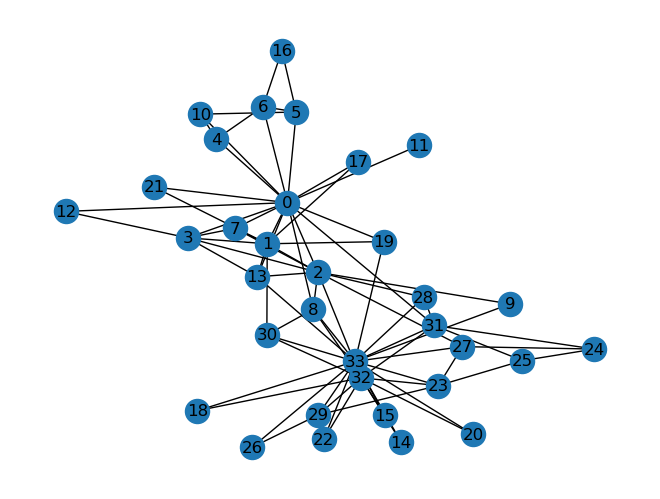

In [11]:
g = nx.karate_club_graph()
nx.draw(g, with_labels=True)

## 1. 請延續實作的範例，完成 Blockmodelling 的分析。

Step1. 建立 `sim_matrix`

In [12]:
sim = nx.simrank_similarity(g)
nodes = sorted(g.nodes())
sim_matrix = np.zeros((len(nodes), len(nodes)))
block_matrix = []

for i, u in enumerate(nodes):
    for j, v in enumerate(nodes):
        sim_matrix[i, j] = sim[u][v]

Step2. 使用相似度矩陣進行階層聚類
* 將相似度轉換為距離（1 - similarity）
* 獲取距離矩陣的濃縮形式（只需上三角）

In [13]:

distance_matrix = 1 - sim_matrix
condensed_dist = squareform(distance_matrix, checks=False)
Z = linkage(condensed_dist, method="ward")

Step3. 使用肘部法則自動決定最佳集群數量

Number of clusters: 2


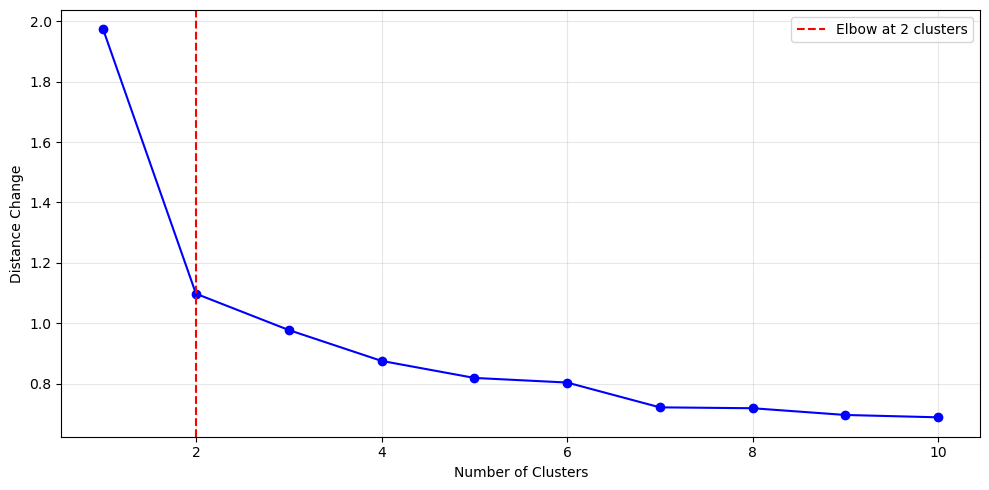

In [14]:
# calculate distance change in different clusters
last = Z[-10:, 2]
last_rev = last[::-1]
idxs = np.arange(1, len(last) + 1)

acceleration = np.diff(last_rev, 2)
elbow_idx = acceleration.argmax() + 2

# Number of clusters
n_clusters = elbow_idx
print("Number of clusters:" , n_clusters)

# draw 
plt.figure(figsize=(10, 5))
plt.plot(idxs, last_rev, "bo-")
plt.axvline(x=elbow_idx, color="r", linestyle="--", label=f"Elbow at {elbow_idx} clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Distance Change")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
    

Step4. 建立塊模型矩陣

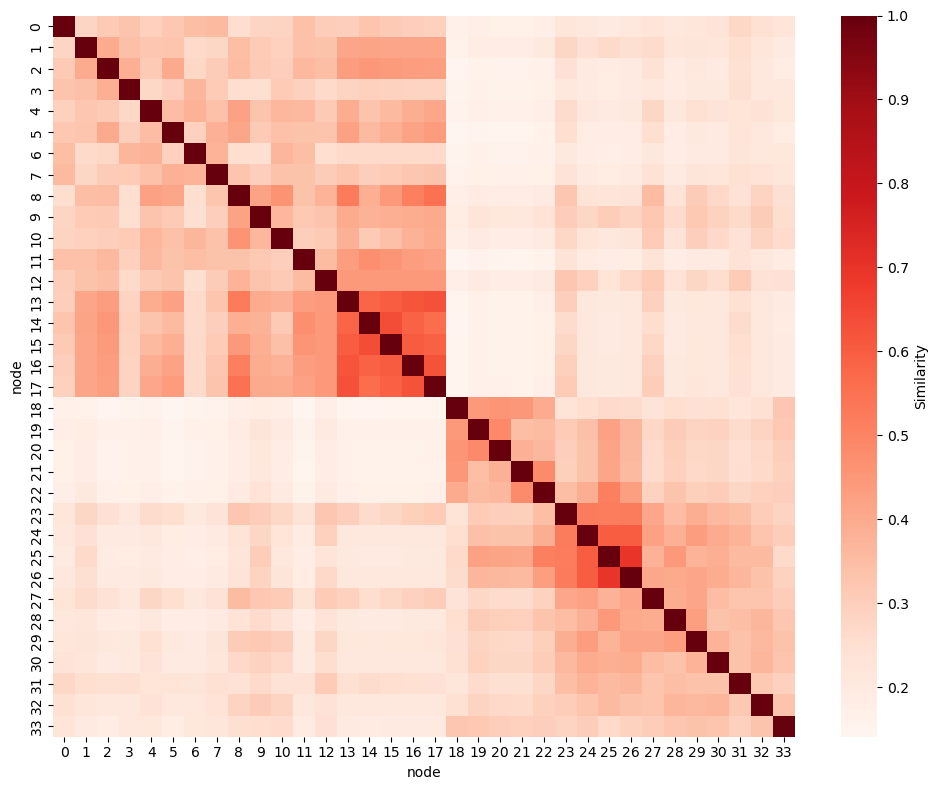

In [ ]:
clusters = fcluster(Z, n_clusters, criterion="maxclust")
cluster_order = np.argsort(clusters)  # reorder by clusters
reordered_sim = sim_matrix[cluster_order][:, cluster_order]
reordered_clusters = clusters[cluster_order]

# draw
plt.figure(figsize=(10, 8))
sns.heatmap(reordered_sim, cmap="Reds", cbar_kws={"label": "Similarity"})
plt.xlabel("node")
plt.ylabel("node")
plt.tight_layout()
plt.show()


Step5. 區塊模型矩陣 (集群間的平均相似度)

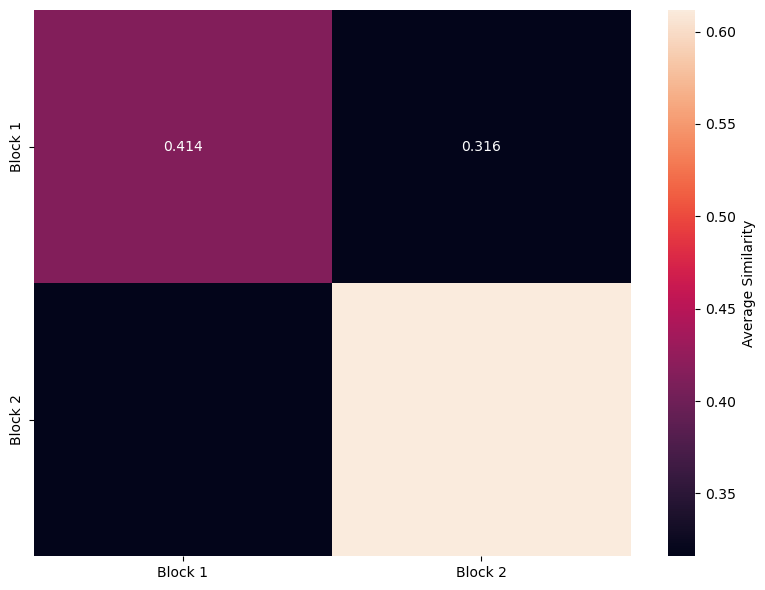

In [16]:
cluster_sizes = np.bincount(reordered_clusters)
cluster_boundaries = np.cumsum(cluster_sizes)[:-1]
block_matrix = np.zeros((n_clusters, n_clusters))

for i in range(n_clusters):
    for j in range(n_clusters):
        temp1 = np.where(clusters == i + 1)[0]
        temp2 = np.where(clusters == j + 1)[0]
        
        if ((len(temp1) > 0) and (len(temp2) > 0)):
            block_matrix[i, j] = np.mean(sim_matrix[np.ix_(temp1, temp2)])

# draw
plt.figure(figsize=(8, 6))
sns.heatmap(block_matrix, annot=True, fmt=".3f", xticklabels=[f"Block {i+1}" for i in range(n_clusters)], yticklabels=[f"Block {i+1}" for i in range(n_clusters)], cbar_kws={"label": "Average Similarity"})
plt.tight_layout()
plt.show()

## 2. 請問空手道俱樂部的網絡中，是否存在「完全」結構等位的 Pair ？

In [17]:
list1 = []

for i in range(len(nodes)):
    for j in range(i + 1, len(nodes)):
        if (np.allclose(sim_matrix[i], sim_matrix[j])):
            list1.append((nodes[i], nodes[j]))

if (len(list1) > 0):
    print("There are", len(list1), "structural equivalence pairs.")

    for i in list1:
        print("node", i[0], "& node", i[1])
else:
    print("There is not any structural equivalence pairs.")

There is not any structural equivalence pairs.
